# EDA 05.02 — Target and Temporal Analysis

All calculations use `master_dataset_clean.parquet`. The source dataset is not modified.

In [1]:
# Import libraries
from pathlib import Path
import sys
from IPython.display import Image, display

In [2]:
# define the root directory of the project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'eda.yaml'
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/eda.yaml')

In [3]:
# Import module to manage the EDA process
from src.ontario_peak_risk.eda.common import (
    load_eda_config,
    prepare_output_directories,
    load_clean_dataset,
)


In [4]:
# Config EDA process and Load the dataset
CONFIG, _ = load_eda_config(CONFIG_PATH)
REPORTS_DIR, FIGURES_DIR, DOCS_DIR = prepare_output_directories(CONFIG, PROJECT_ROOT)
dataset = load_clean_dataset(CONFIG, PROJECT_ROOT)
TARGET = CONFIG['columns']['target']

dataset.shape

(262944, 66)

In [5]:
# Import the function to run the target temporal
from src.ontario_peak_risk.eda.target_temporal import run_target_temporal

In [6]:
# Generate the target and temporal analysis of the dataset and save the results in the output directories
results = run_target_temporal(
    dataset,
    TARGET,
    CONFIG['analysis']['autocorrelation_lags'],
    REPORTS_DIR,
    FIGURES_DIR,
    DOCS_DIR,
)

print("Target and temporal analysis completed.")

Target and temporal analysis completed.


In [7]:
# Display the available result objects
results.keys()

dict_keys(['statistics', 'by_fsa', 'autocorrelation', 'hour_month_heatmap', 'year', 'month', 'weekday', 'hour', 'season', 'daily'])

In [8]:
# Display descriptive statistics for the target variable
results["statistics"]

,count,mean,median,standard_deviation,minimum,p01,p05,p25,p75,p95,p975,p99,maximum,skewness
0,262944,8792.717022,8111.4,4312.827798,1377.7,2586.329,3359.9,5224.9,11544.0,16622.985,18340.1,21178.17,33712.2,0.849491


In [9]:
# Display selected target percentiles
results["statistics"][
    [
        "minimum",
        "p01",
        "p05",
        "p25",
        "median",
        "p75",
        "p95",
        "p975",
        "p99",
        "maximum",
    ]
]

,minimum,p01,p05,p25,median,p75,p95,p975,p99,maximum
0,1377.7,2586.329,3359.9,5224.9,8111.4,11544.0,16622.985,18340.1,21178.17,33712.2


In [10]:
# Display target statistics by FSA
results["by_fsa"]

,fsa,count,mean,median,standard_deviation,minimum,maximum
0,L4T,43824,11617.975148,11179.00,3441.406039,5864.4,27796.6
1,M5R,43824,7662.036624,7461.00,2019.435360,3721.5,16999.0
2,M5S,43824,4108.749952,4044.75,986.417349,2060.4,7622.4
3,M6G,43824,11488.117506,11243.00,3177.874939,4954.9,27460.1
4,M9R,43824,5542.009675,5211.95,1899.714503,1377.7,16243.6
5,M9W,43824,12337.413226,11916.35,4405.017340,4361.1,33712.2


In [11]:
# Display annual electricity-consumption profile
results["year"]

,year,mean,median,max
0,2021,8002.746277,7439.25,25152.4
1,2022,8096.373202,7555.60,26563.9
2,2023,9024.425091,8428.95,29812.2
3,2024,9173.723072,8542.60,30178.2
4,2025,9665.273615,9023.20,33712.2


In [12]:
# Display monthly electricity-consumption profile
results["month"]

,month,month_name,mean,median,max
0,1,January,9722.038163,9442.75,20741.6
1,2,February,9559.227827,9361.85,20316.3
2,3,March,8604.547527,8265.70,19194.4
3,4,April,7677.193148,7225.30,17496.3
4,5,May,7344.538217,6699.15,23875.9
5,6,June,9103.121565,8131.40,33712.2
6,7,July,10666.268535,9590.80,31498.5
7,8,August,10059.607142,9151.90,32007.9
8,9,September,7997.808463,7174.75,29812.2
9,10,October,7261.917944,6681.60,22256.3


In [13]:
# Display electricity-consumption profile by weekday
results["weekday"]

,weekday,weekday_name,mean,median,max
0,0,Monday,8822.537920,8184.50,33203.0
1,1,Tuesday,8776.460135,8116.35,33712.2
2,2,Wednesday,8757.159525,8103.15,30583.0
3,3,Thursday,8647.107909,7989.95,31498.5
4,4,Friday,8636.937348,7993.70,28123.7
5,5,Saturday,8882.759571,8135.30,30235.6
6,6,Sunday,9025.498856,8264.90,31248.5


In [14]:
# Display hourly electricity-consumption profile
results["hour"]

,hour,mean,median,max
0,0,7208.517132,6967.75,22467.1
1,1,6663.884237,6435.40,21117.2
2,2,6319.929208,6128.10,19950.2
3,3,6163.650438,6013.85,19302.8
4,4,6211.503058,6063.25,19199.7
5,5,6472.374142,6349.30,19763.2
6,6,7026.709191,6939.70,21927.3
7,7,7719.649306,7709.25,24795.9
8,8,8335.850475,8267.25,27452.9
9,9,8892.948248,8729.55,29556.6


In [15]:
# Display seasonal electricity-consumption profile
results["season"]

,season,mean,median,max
0,Winter,9547.415650,9270.50,20741.6
1,Spring,7877.581005,7317.25,23875.9
2,Summer,9952.128184,8951.85,33712.2
3,Fall,7797.693619,7135.75,29812.2


In [16]:
# Display the first daily aggregated observations
results["daily"].head()

,date_analysis,total,mean,maximum
0,2021-01-01,1199266.2,8328.237500,15086.9
1,2021-01-02,1210297.9,8404.846528,15760.5
2,2021-01-03,1231790.8,8554.102778,16191.8
3,2021-01-04,1201745.7,8345.456250,15722.4
4,2021-01-05,1192516.3,8281.363194,15770.1


In [17]:
# Display the most recent daily aggregated observations
results["daily"].tail()

,date_analysis,total,mean,maximum
1821,2025-12-27,1562670.6,10851.879167,18466.6
1822,2025-12-28,1524893.2,10589.536111,18380.9
1823,2025-12-29,1510860.7,10492.088194,18844.4
1824,2025-12-30,1607698.0,11164.569444,19221.8
1825,2025-12-31,1602888.5,11131.170139,18701.7


In [18]:
# Display selected autocorrelations by FSA
results["autocorrelation"]

,fsa,lag_hours,autocorrelation
0,L4T,1,0.975482
1,L4T,24,0.916333
2,L4T,48,0.834719
3,L4T,168,0.765211
4,M5R,1,0.973775
5,M5R,24,0.927628
6,M5R,48,0.850673
7,M5R,168,0.740614
8,M5S,1,0.971764
9,M5S,24,0.936118


In [19]:
# Display the first rows of the Month × Hour heatmap dataset
results["hour_month_heatmap"].head()

,month,hour,mean_consumption_kwh
0,1,0,8430.465591
1,1,1,7842.129355
2,1,2,7468.833871
3,1,3,7274.497419
4,1,4,7259.858710


In [20]:
# Display the Month × Hour mean-consumption matrix
results["hour_month_heatmap"].pivot(
    index="month",
    columns="hour",
    values="mean_consumption_kwh",
)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
month,,,,,,,,,,,,,,,,,,,,,
1,8430.465591,7842.129355,7468.833871,7274.497419,7259.858710,7465.606129,7853.142688,8503.210538,9137.942473,9632.433441,...,10549.977097,10617.424731,11025.432473,11857.990538,12189.092258,12032.998387,11680.780215,11100.501720,10247.273226,9284.240323
2,8380.489835,7809.922813,7455.080024,7277.180969,7278.068085,7503.245508,7937.081087,8627.126005,9167.960757,9573.659929,...,10178.205792,10213.998109,10532.571395,11202.838180,11837.099764,11817.275059,11498.419504,10936.771040,10100.892435,9164.977896
3,7220.293333,6777.899140,6533.407849,6471.126774,6635.941075,6962.215376,7525.085914,8111.416667,8536.494301,8892.950538,...,9171.116452,9276.654731,9593.754301,9987.091935,10477.346452,10635.274301,10270.727634,9577.400000,8679.953978,7838.928172
4,6122.285444,5763.303778,5581.593889,5594.110667,5781.293000,6172.215556,6804.922778,7333.207111,7744.119889,8117.592333,...,8344.671667,8511.427333,8822.333778,9048.102111,9263.379889,9454.223667,9162.208111,8428.240333,7496.867222,6691.493333
5,5724.077312,5294.285054,5051.494946,4982.334839,5113.499570,5446.640430,6099.295376,6705.044301,7194.572473,7649.758065,...,8277.621613,8508.467312,8850.173548,9038.333871,9078.925806,9126.268172,9058.714731,8372.911290,7374.511613,6465.293226
6,7185.320889,6549.379778,6127.599222,5911.072444,5913.680667,6160.919889,6863.216667,7700.827333,8449.660778,9166.654111,...,10865.026111,11196.086222,11567.650778,11679.051889,11531.840111,11265.086667,11088.492889,10432.309889,9282.880333,8142.491333
7,8548.063763,7766.827849,7221.682151,6900.359032,6816.261075,6936.027204,7568.944624,8590.893333,9612.987097,10587.990430,...,13092.937097,13405.594086,13772.060108,13858.876774,13626.333333,13186.178602,12906.083333,12146.829355,10883.388710,9624.055161
8,8066.086667,7354.290215,6862.291935,6575.911398,6516.302258,6621.555806,7109.350000,8032.847312,9012.405806,9981.861613,...,12352.708495,12627.067957,12974.978817,13021.889032,12734.732043,12489.921075,12210.524624,11347.087312,10154.438495,9003.328495
9,6168.345556,5662.314889,5337.940111,5193.124444,5266.400444,5567.872000,6163.580333,6763.390333,7404.587000,8049.235889,...,9560.922556,9883.361111,10217.685444,10276.230333,10292.406333,10275.651556,9766.644444,8900.774444,7843.531667,6890.980000


Generated figures: 14

05_02_autocorrelation_by_fsa.png


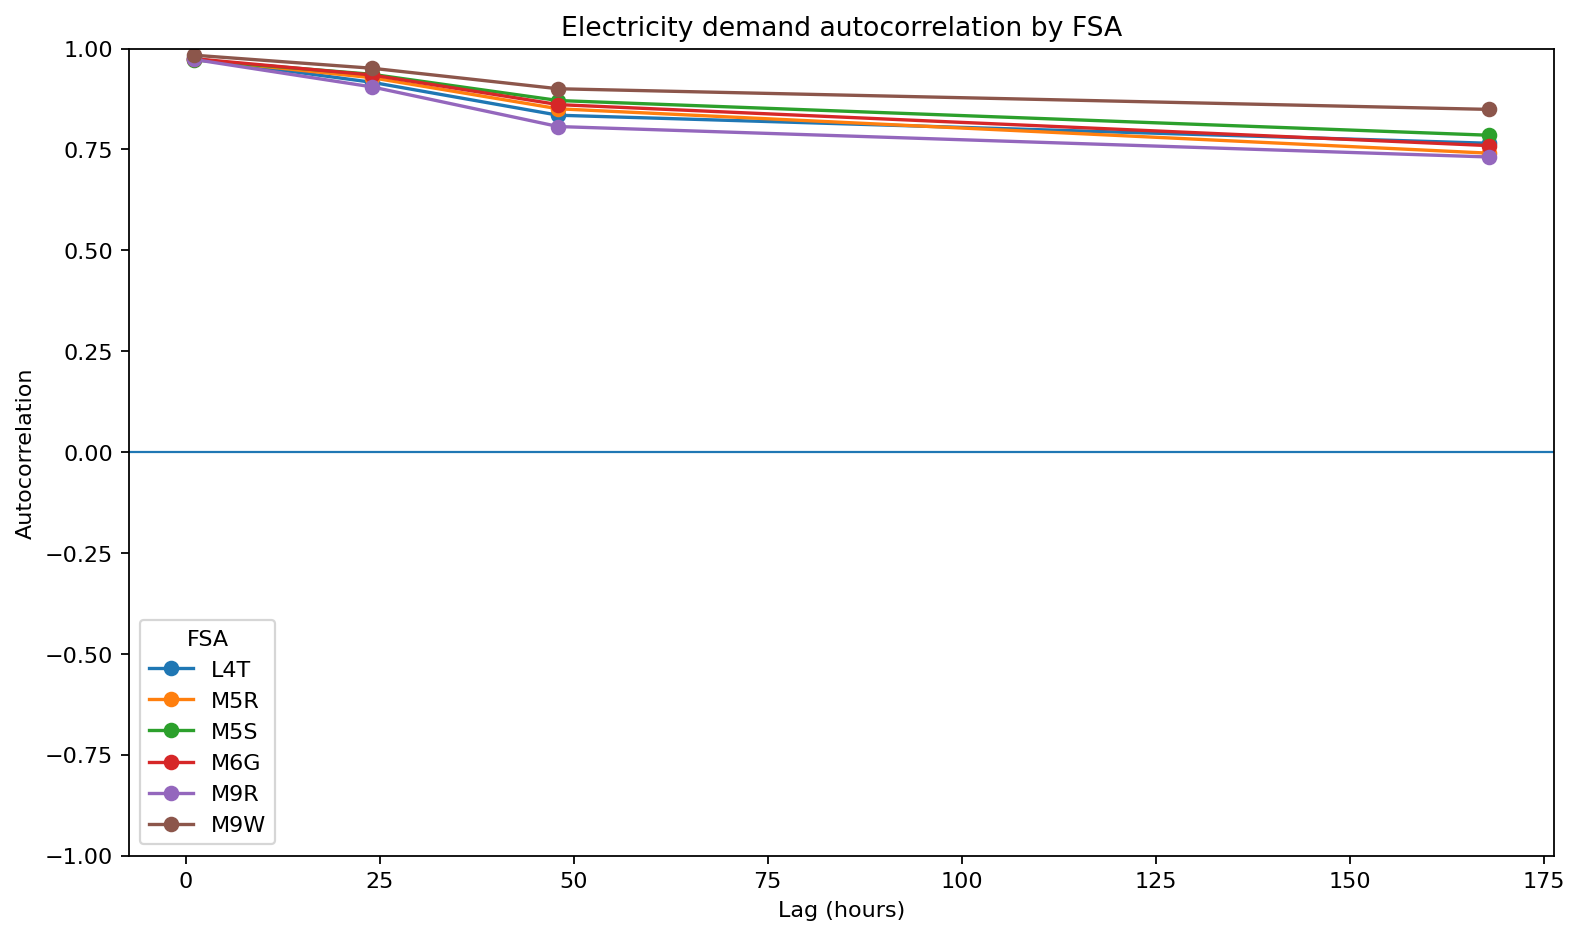


05_02_daily_maximum_p975_exceedances.png


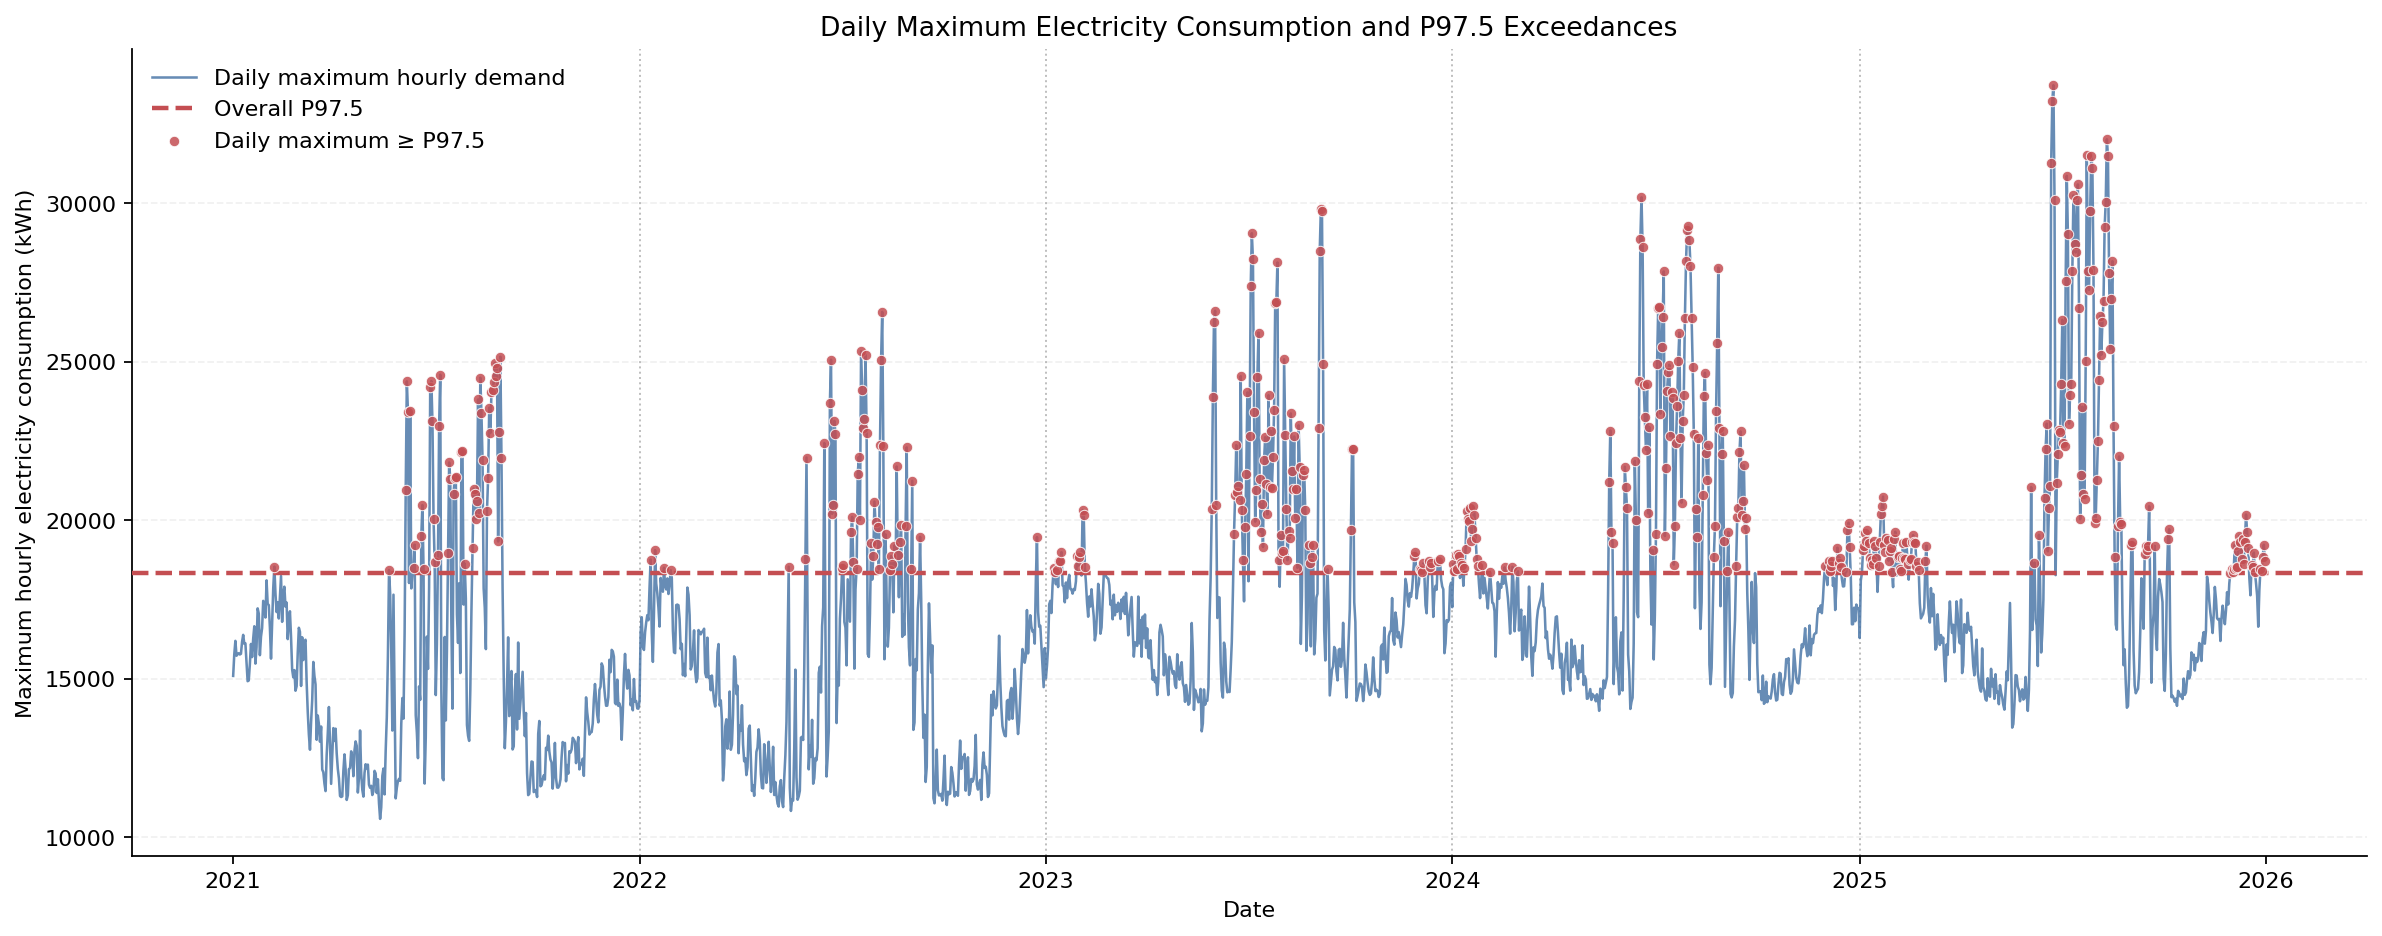


05_02_daily_maximum_p975_exceedances_v2.png


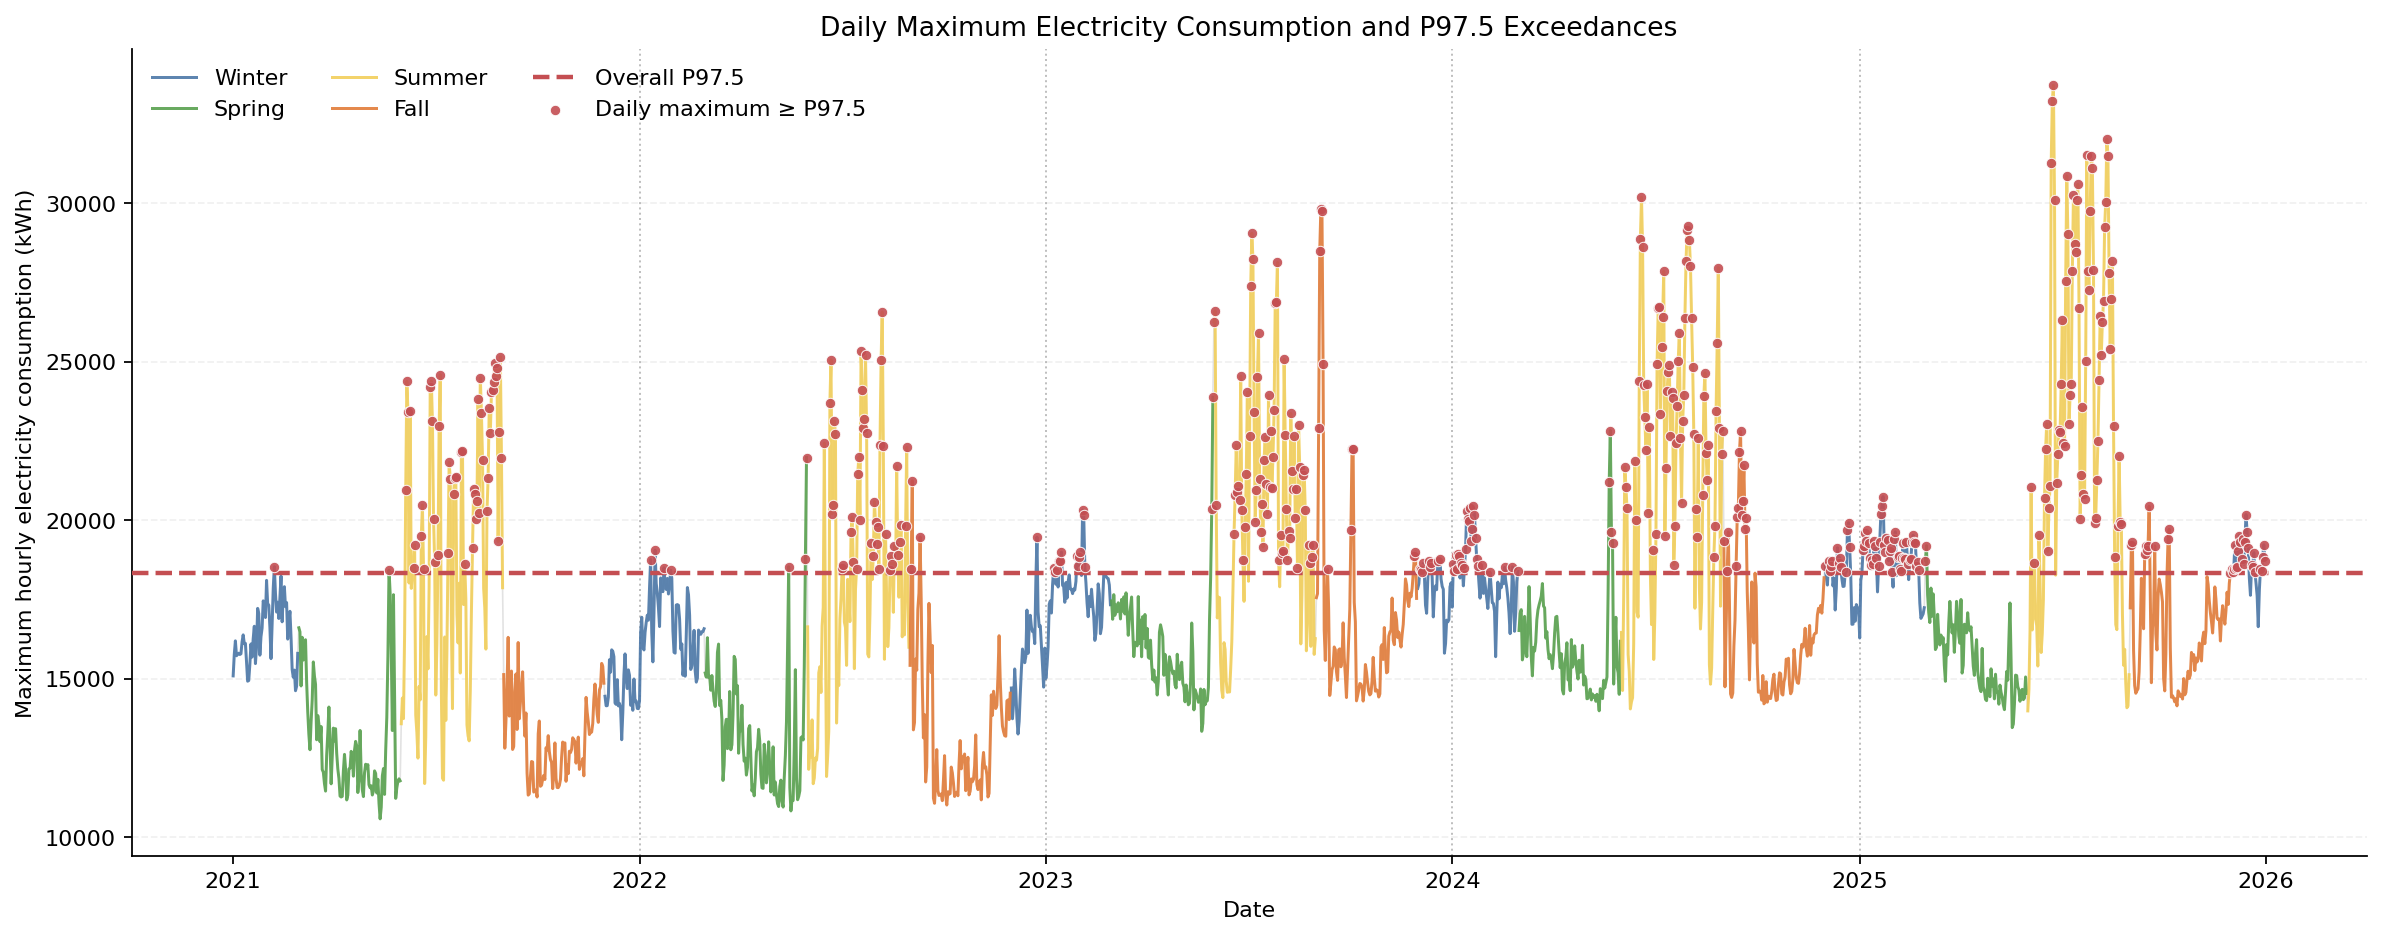


05_02_daily_trend.png


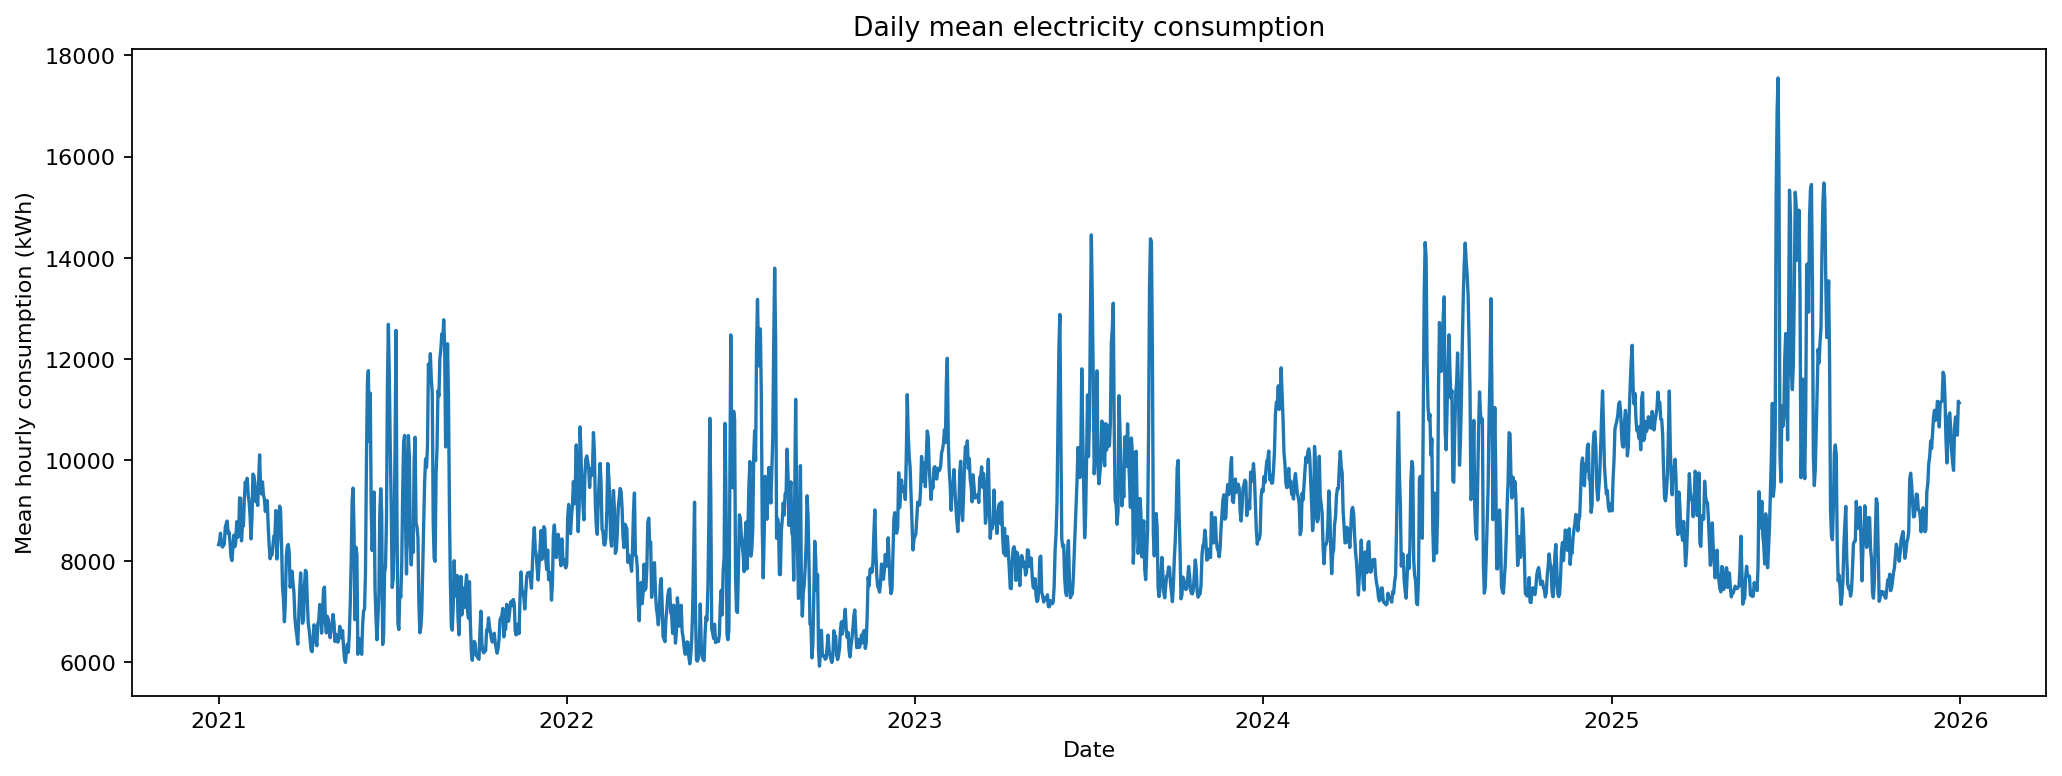


05_02_daily_trend_enhanced.png


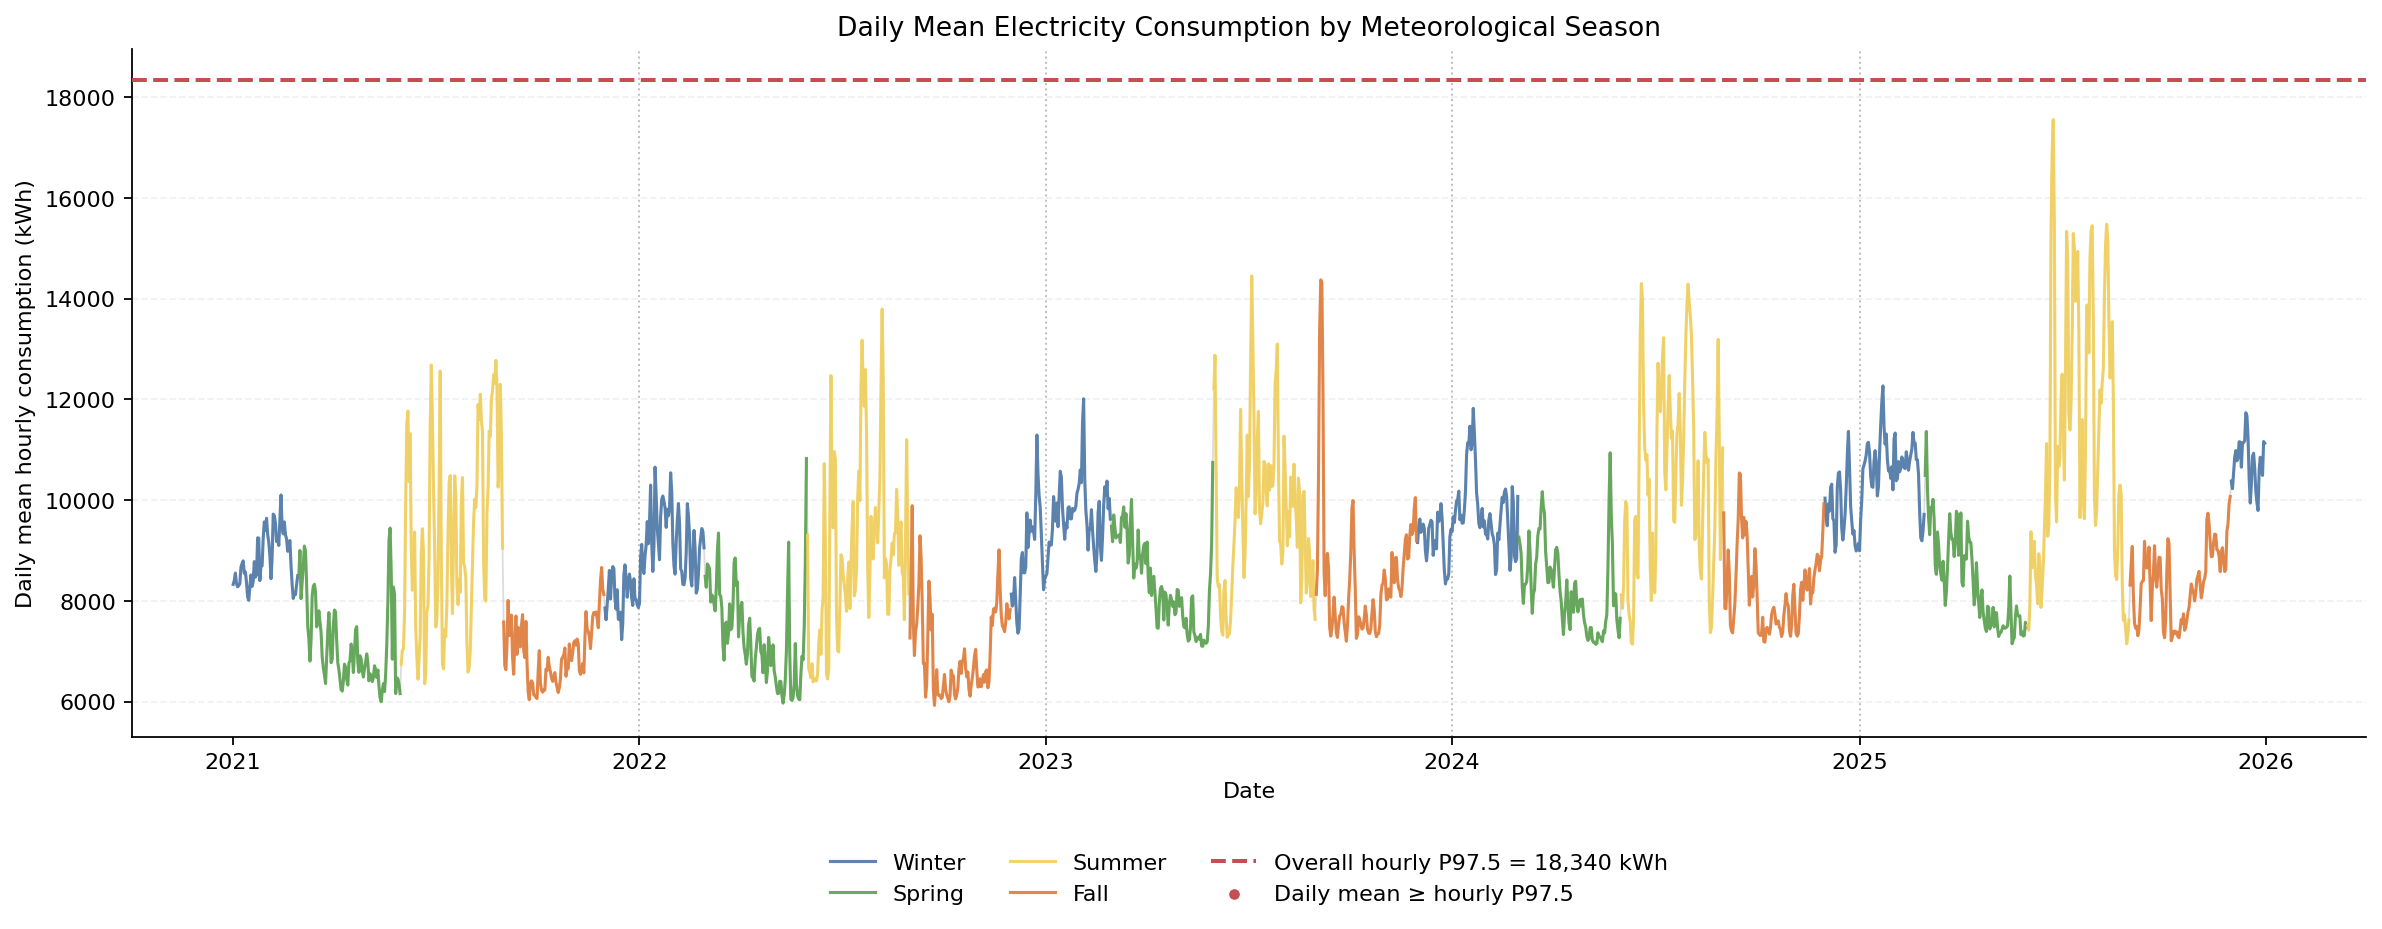


05_02_hour_month_heatmap.png


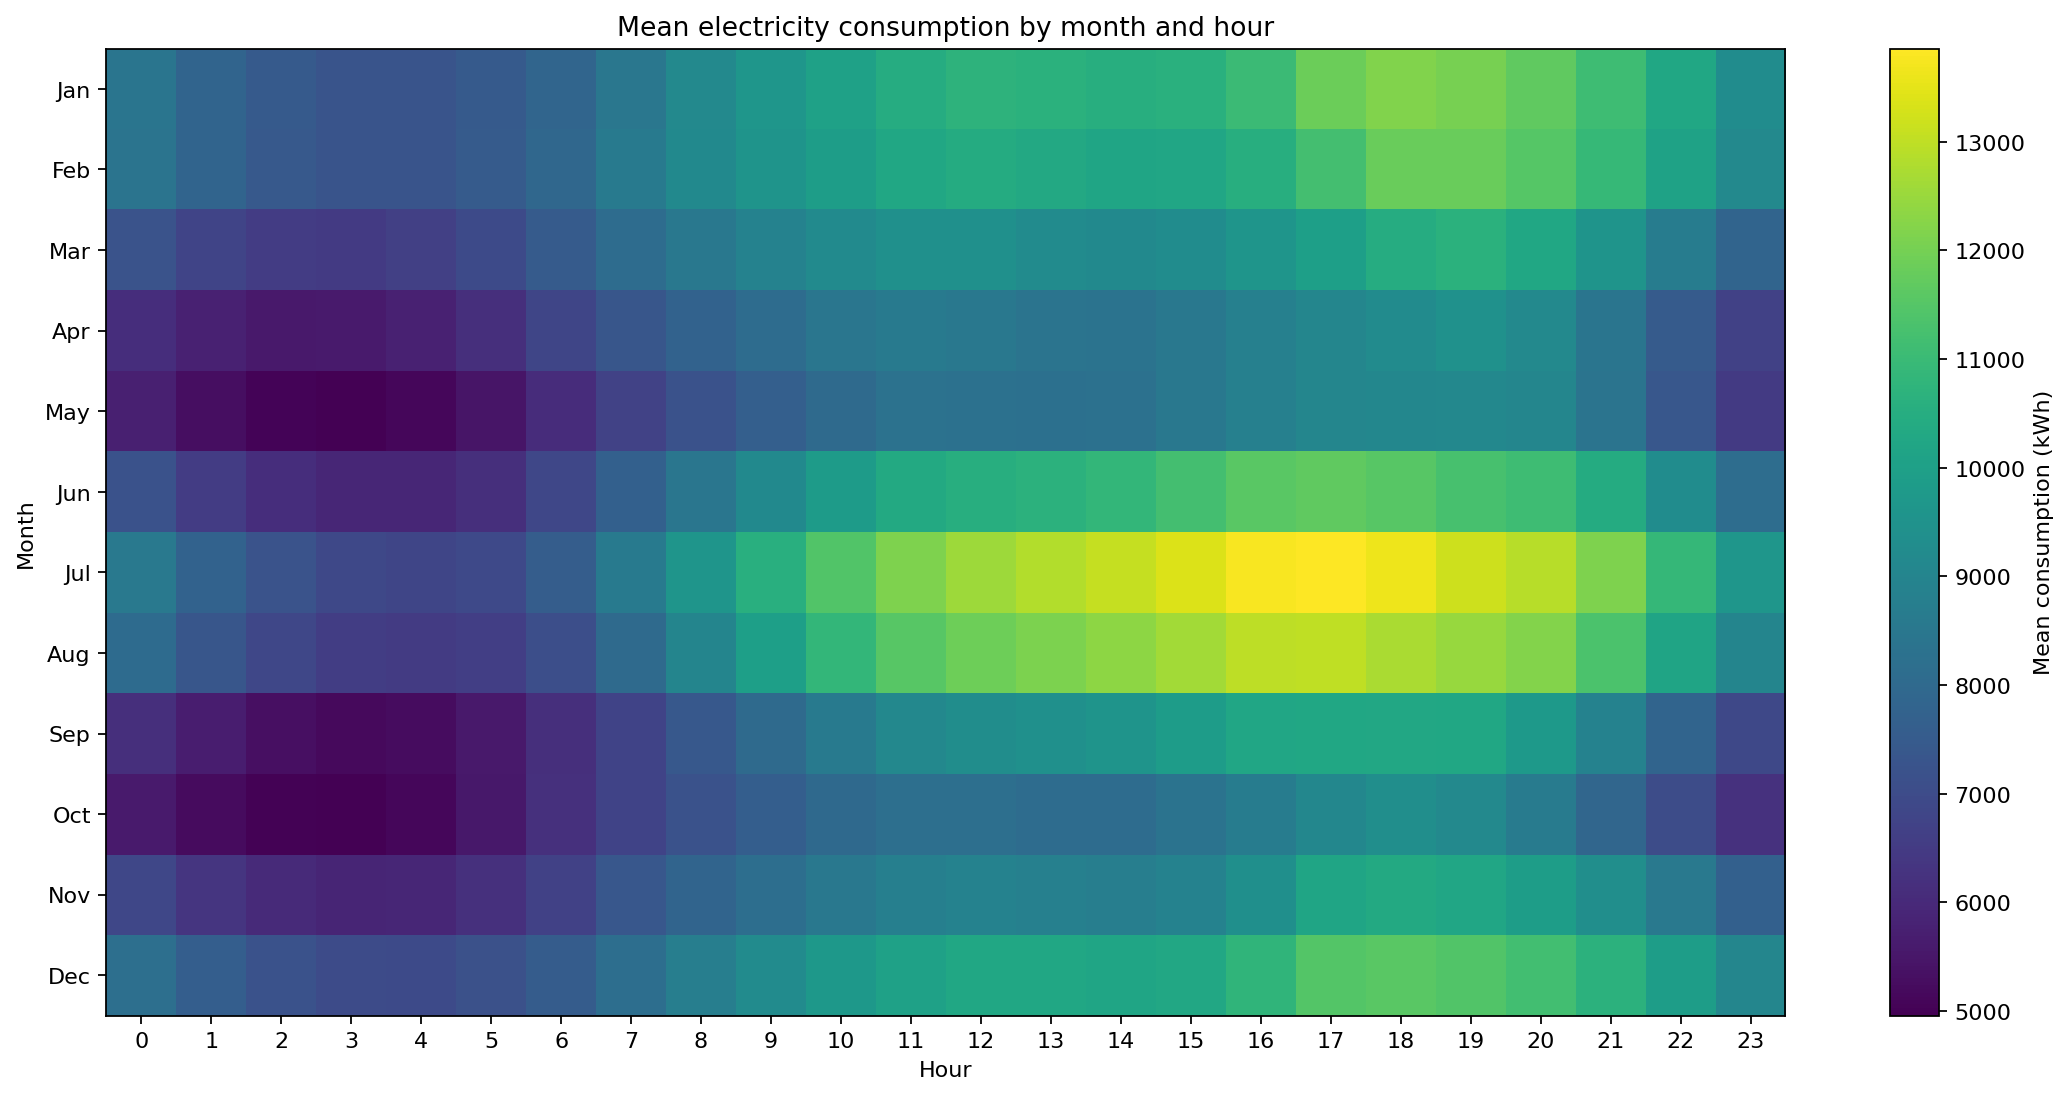


05_02_hourly_boxplot.png


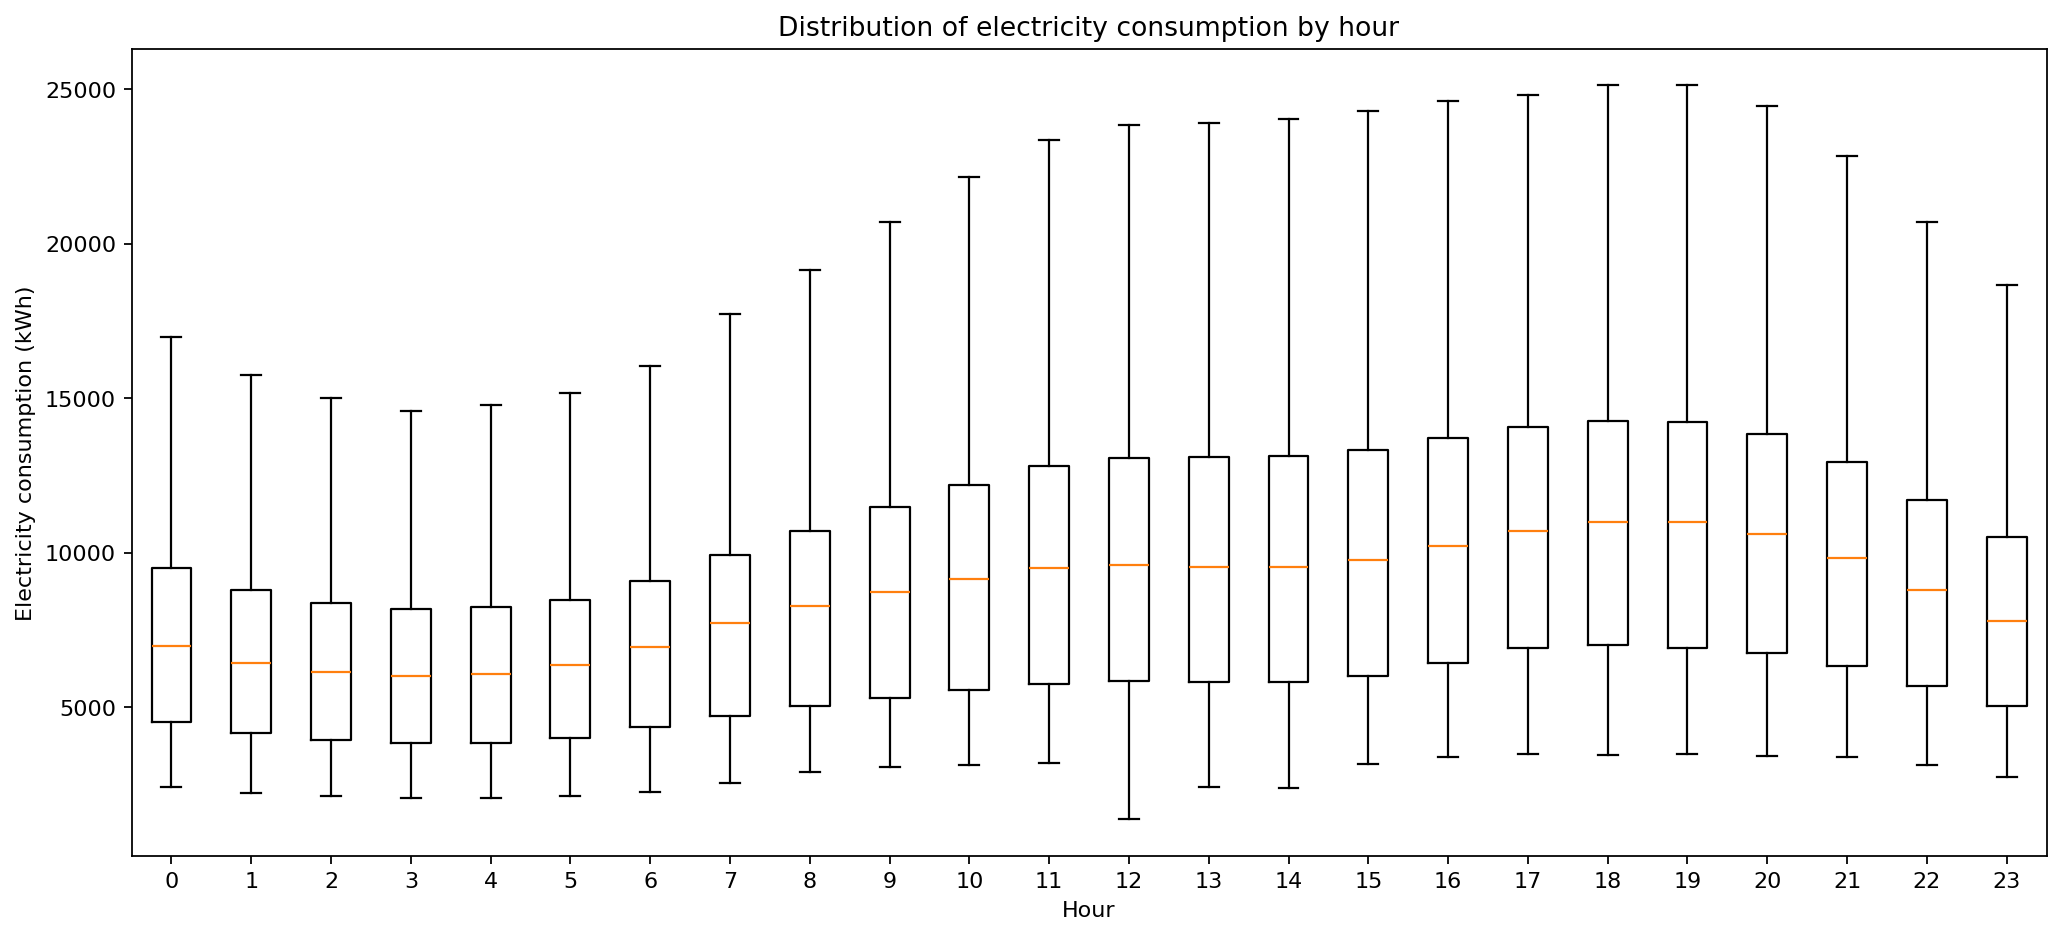


05_02_hourly_profile.png


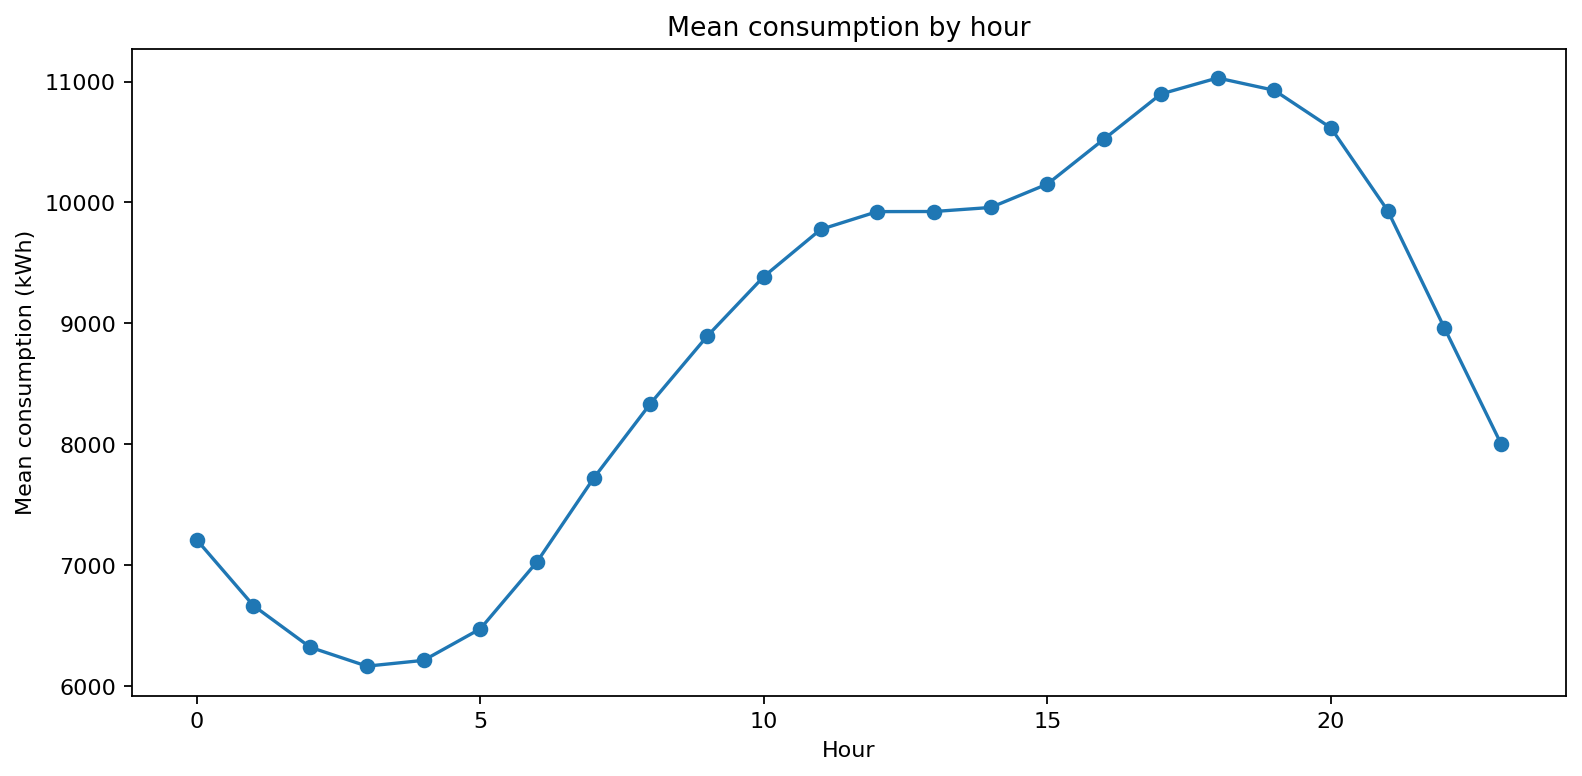


05_02_monthly_profile.png


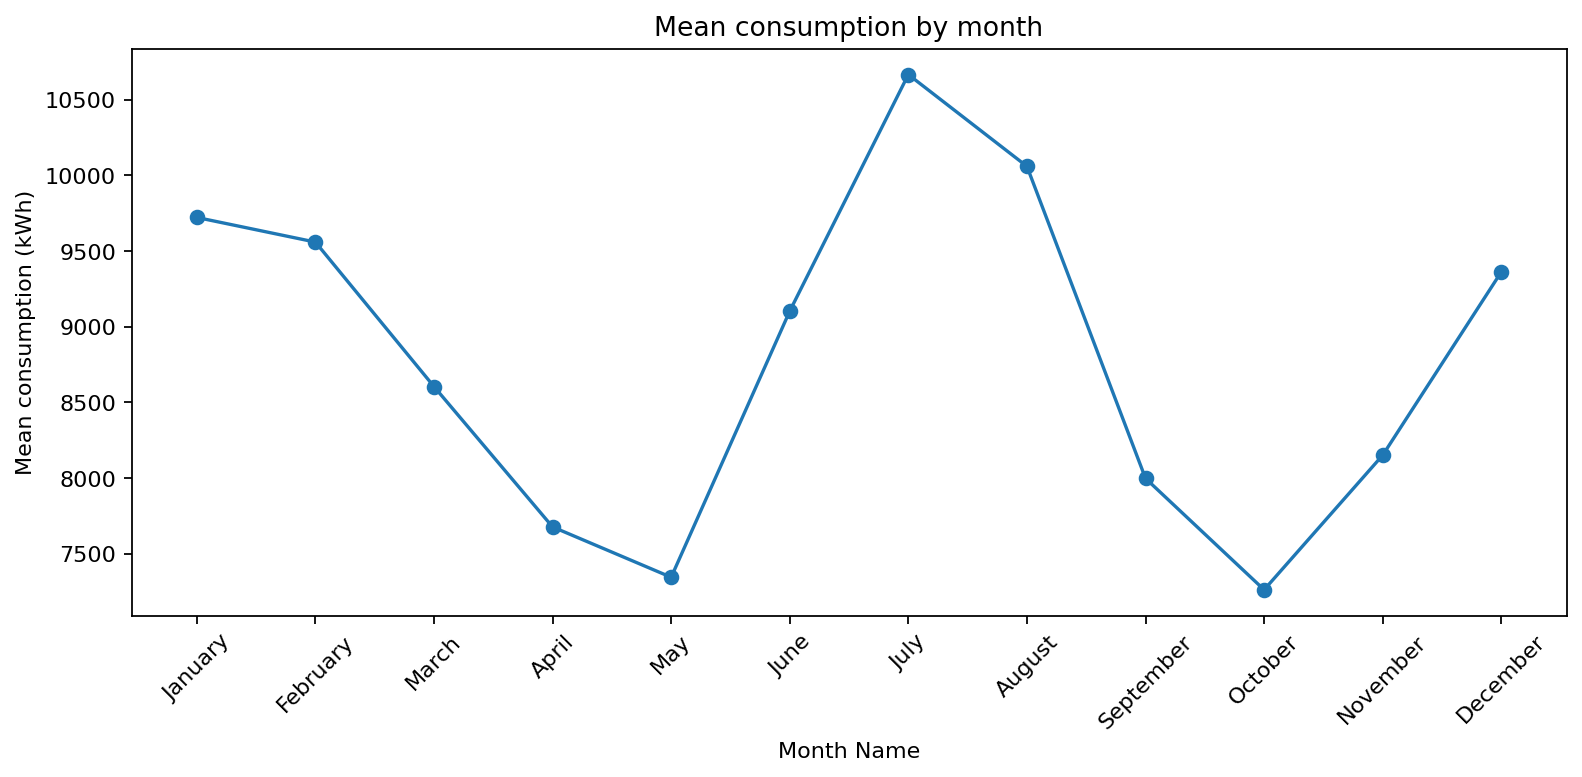


05_02_seasonal_profile.png


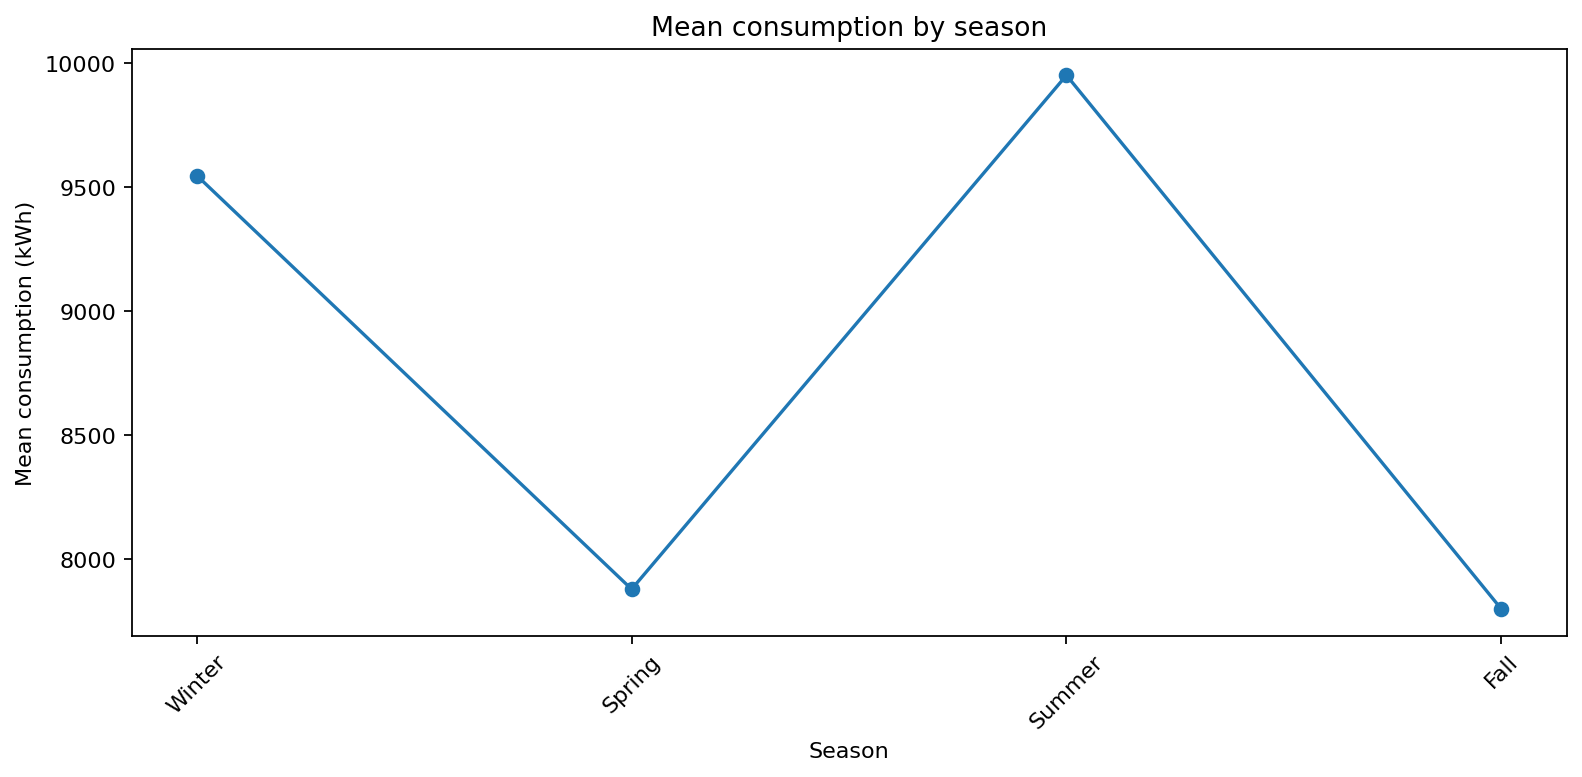


05_02_target_distribution.png


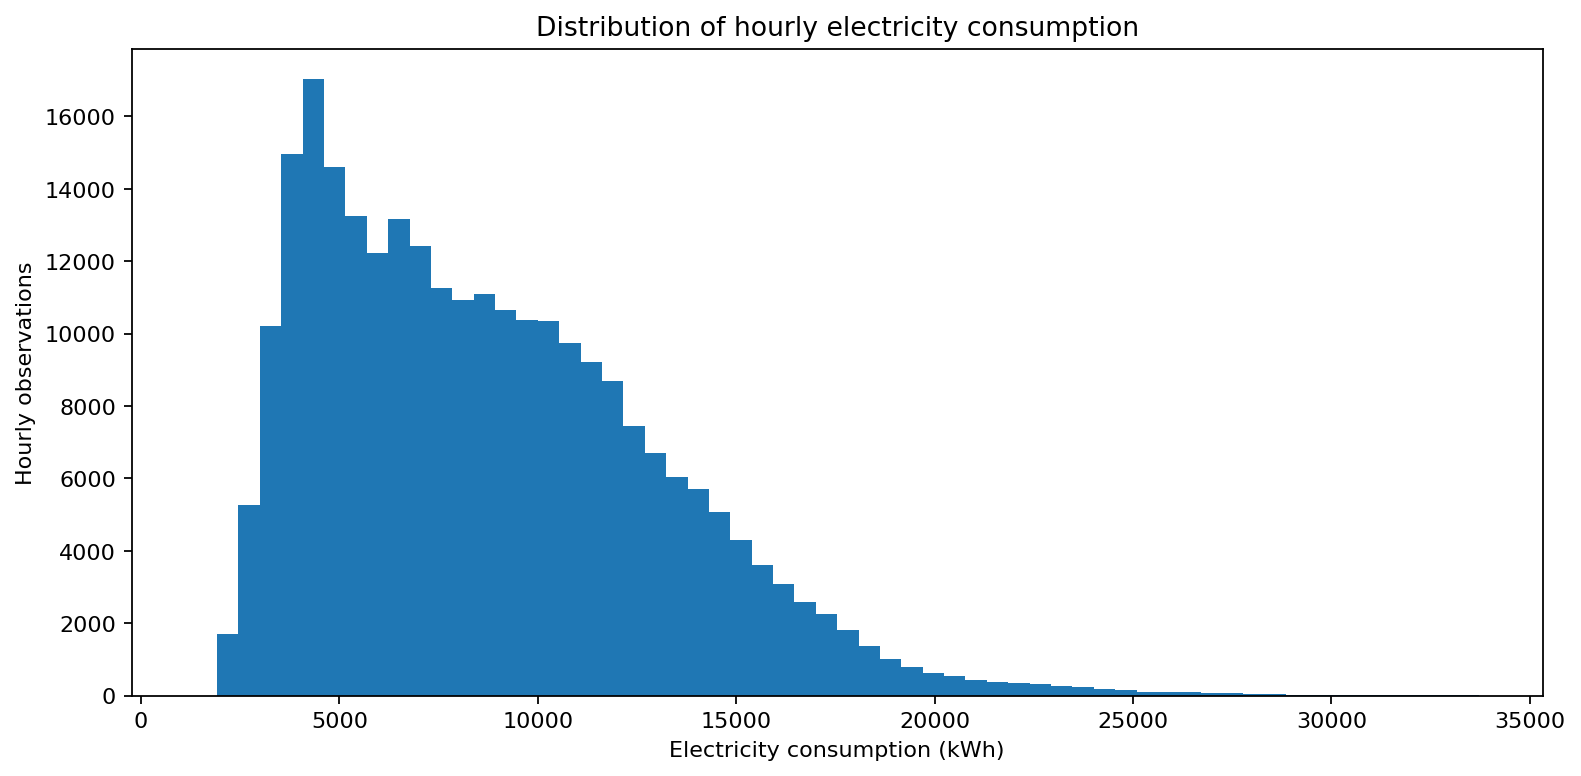


05_02_target_distribution_enhanced.png


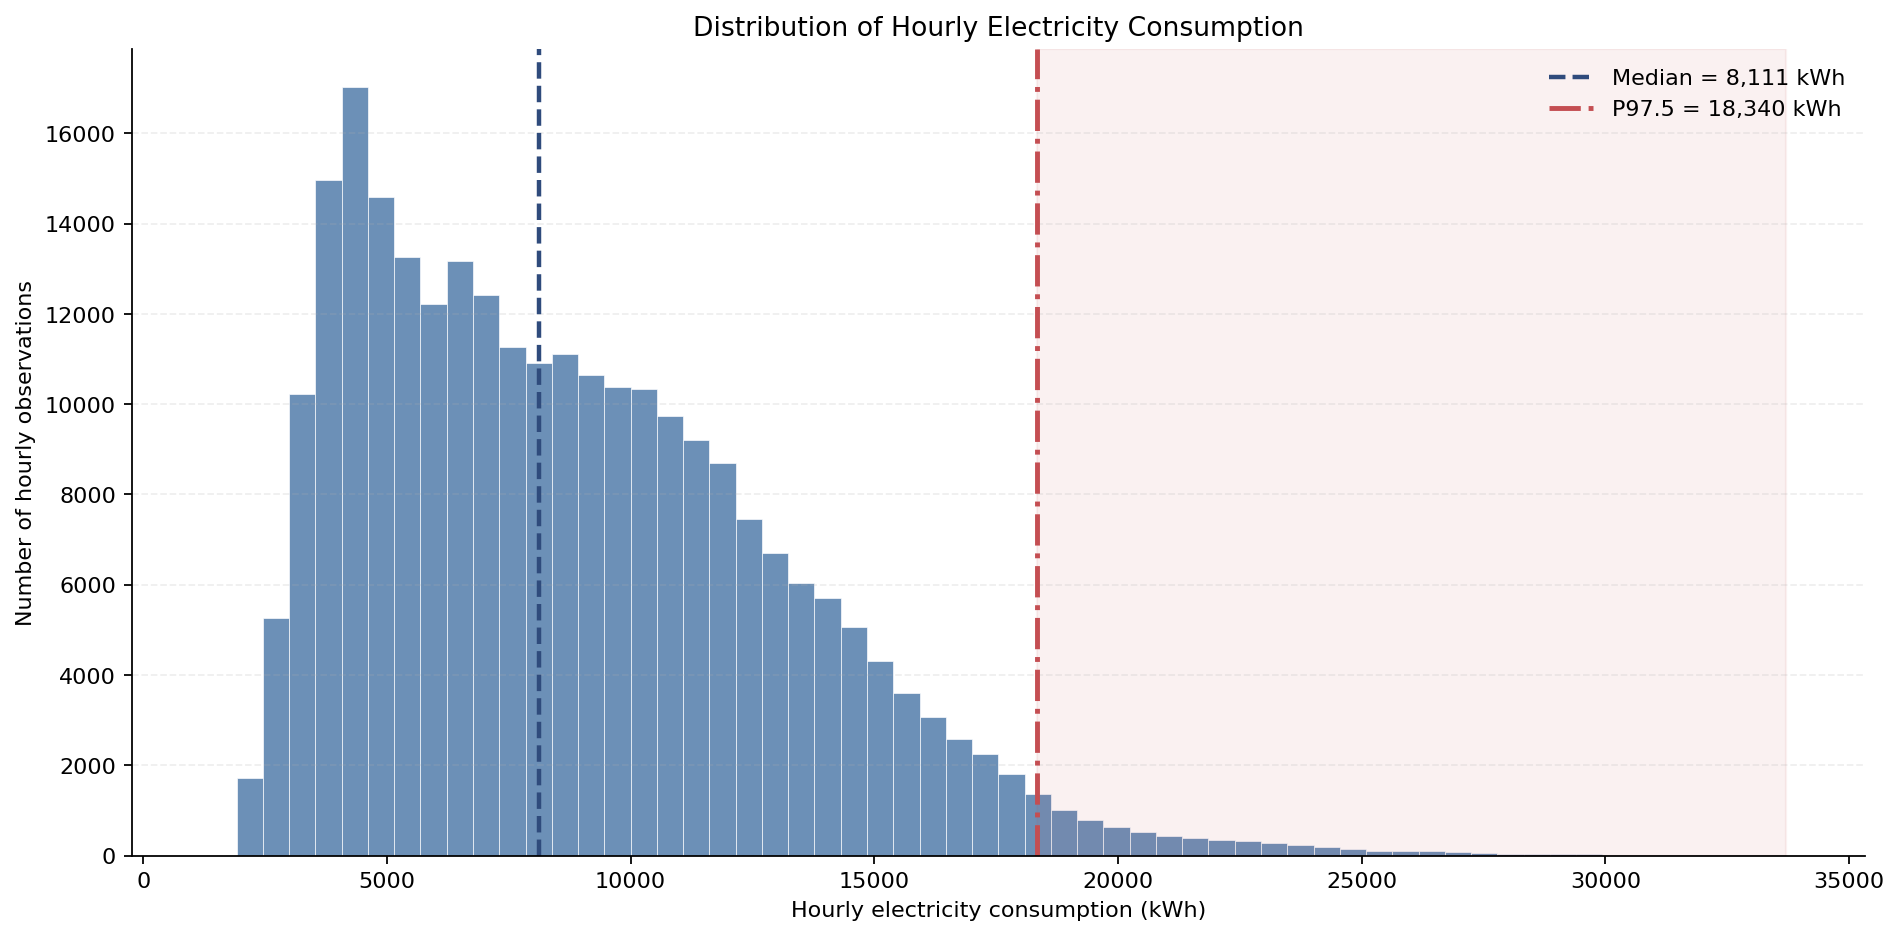


05_02_weekday_boxplot.png


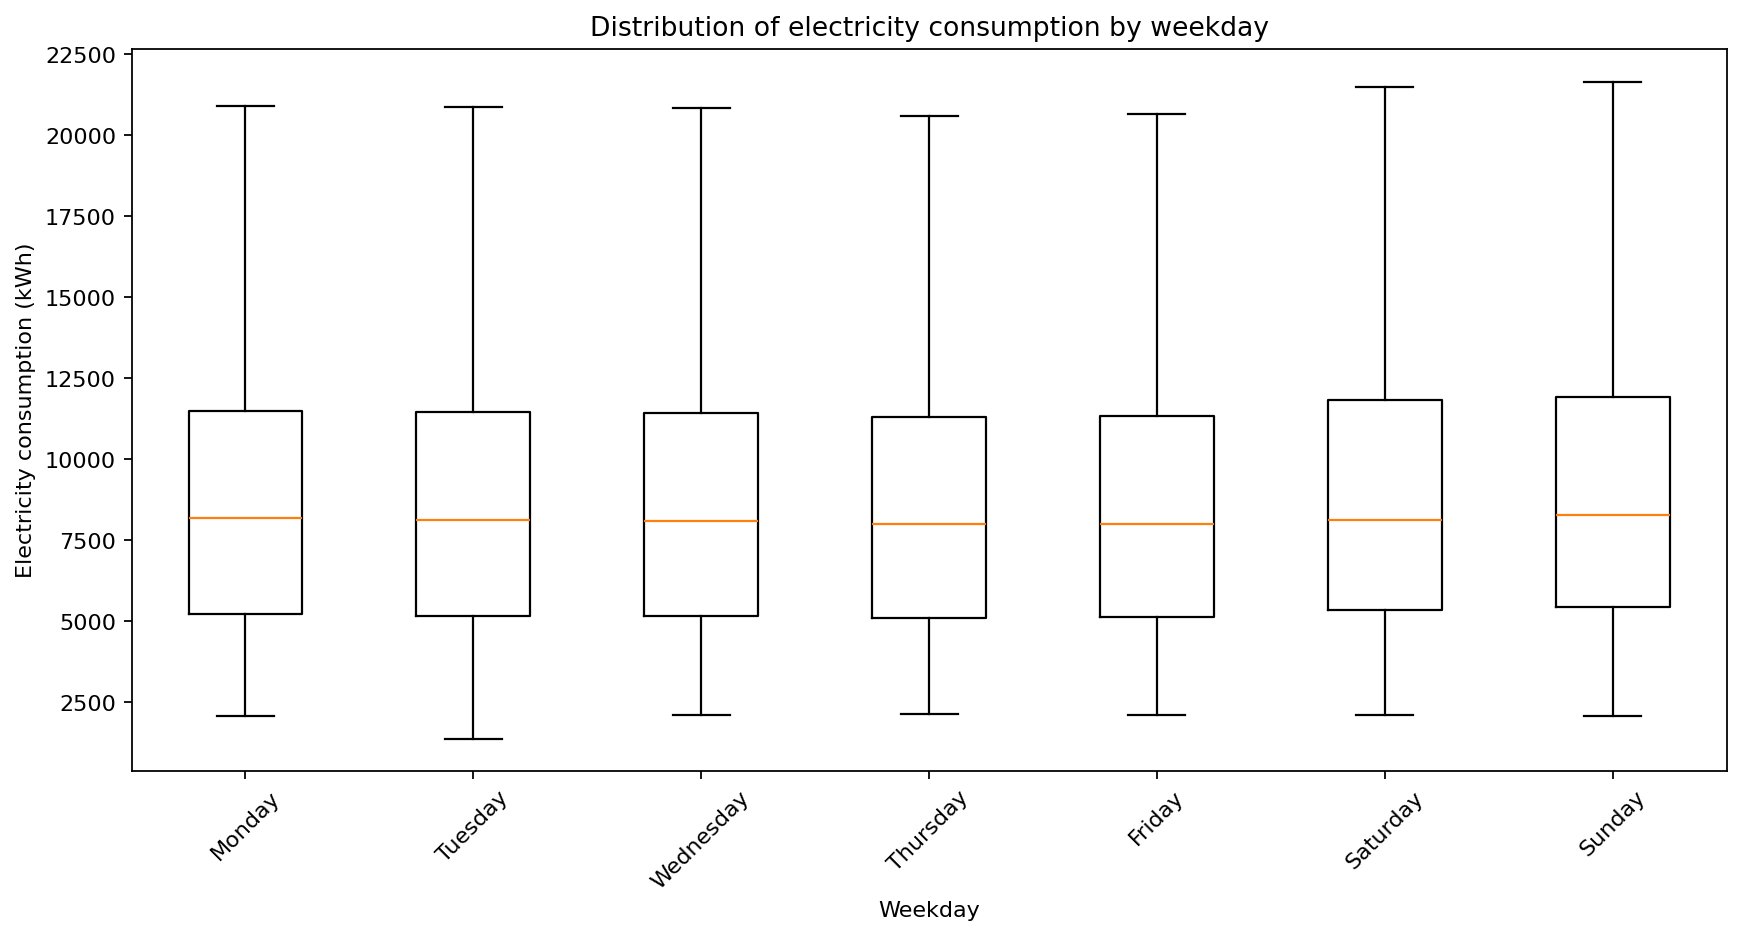


05_02_weekday_profile.png


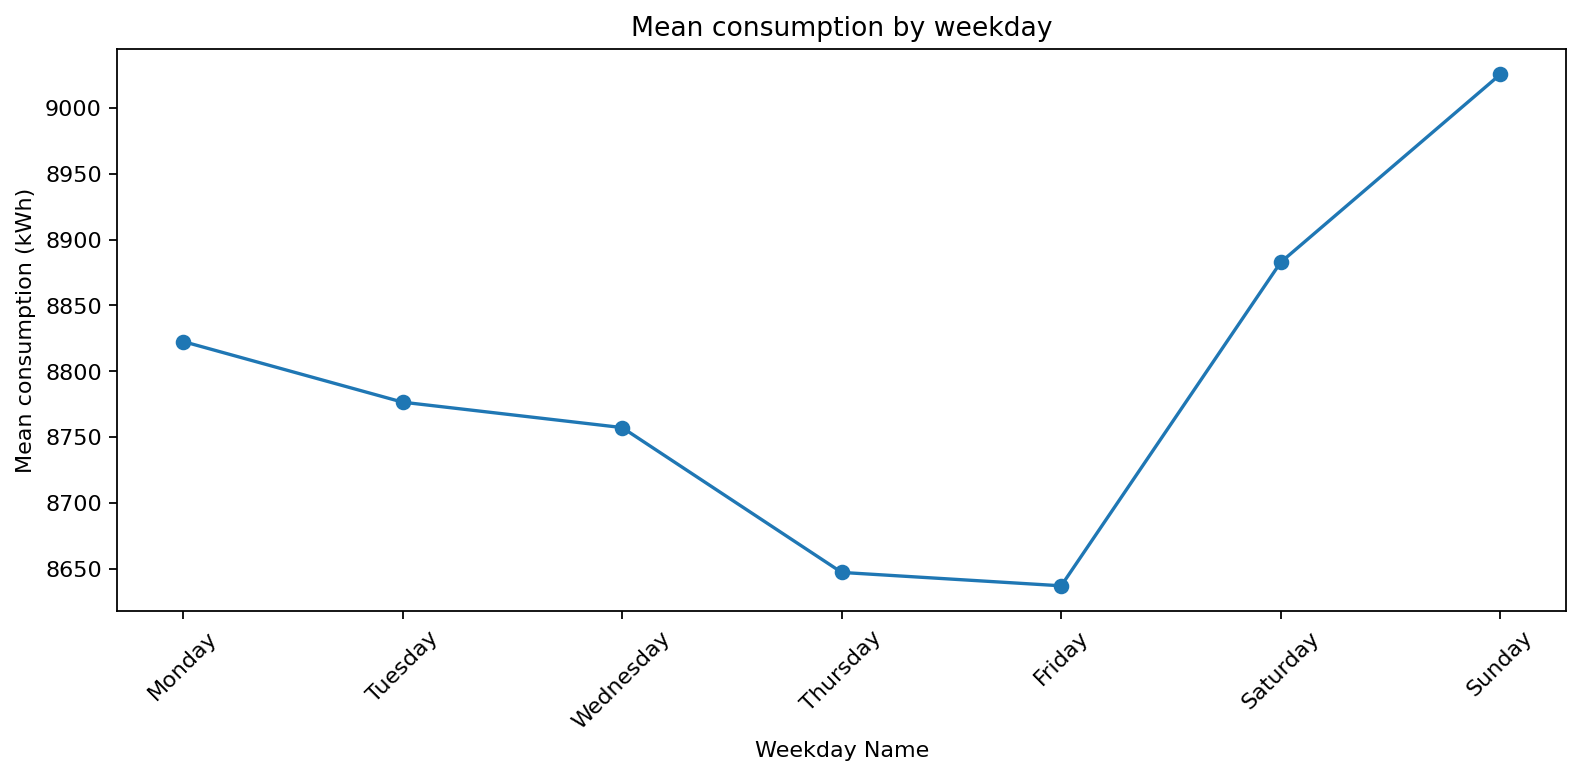

In [21]:
# Display all figures generated by the 05.02 analysis
generated_figures = sorted(
    FIGURES_DIR.glob("05_02_*.png")
)

print(
    f"Generated figures: {len(generated_figures)}"
)

for figure_path in generated_figures:
    print(f"\n{figure_path.name}")
    display(
        Image(
            filename=str(figure_path)
        )
    )

## Summary
Review the generated CSV tables, figures, and Markdown section report.

Review: 
- Report under `docs/eda/05_02_Target_and_Temporal_Analysis.md`.
- CSV reports under `reports/eda/`.